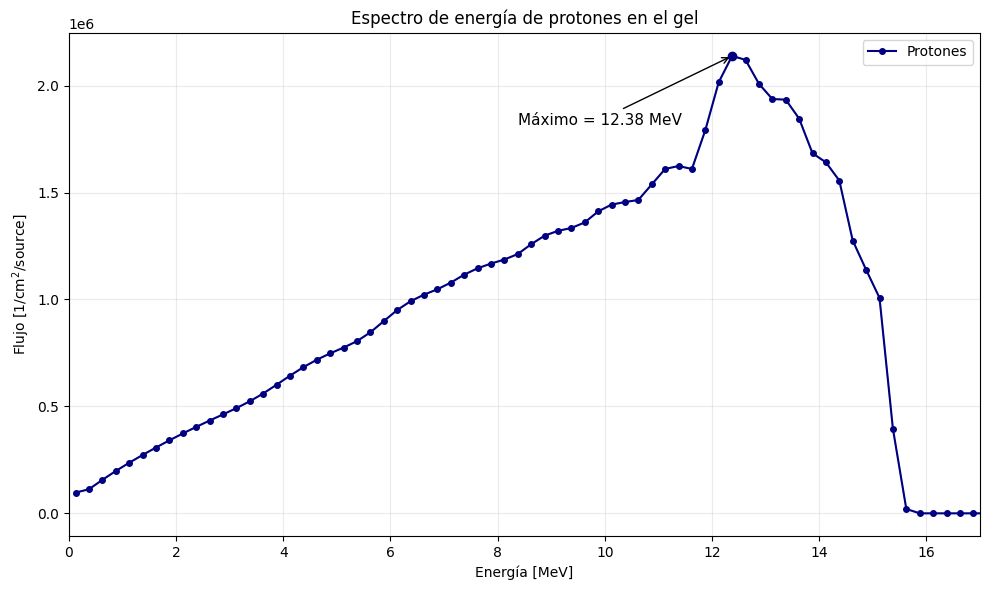

Número de bins: 100
Energía del máximo: 12.3750 MeV
Flujo máximo: 2.1390e+06 1/cm²/source
Energía media ponderada: 9.7674 MeV


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# ARCHIVO
# ============================================================

archivo = r"C:\phits\Laboratory-VII\Modelo irradiacion final\sin_atenuador1mmgel2mmpouch19punto5MeV\out\energy_gel.out"

# ============================================================
# LEER DATOS DEL ESPECTRO
# ============================================================

datos = []

with open(archivo, "r") as f:

    for linea in f:

        linea = linea.strip()

        # Ignorar comentarios y líneas vacías
        if not linea or linea.startswith("#"):
            continue

        partes = linea.split()

        # Nos quedamos solamente con las líneas que tienen
        # 4 columnas numéricas
        if len(partes) == 4:

            try:
                datos.append([
                    float(partes[0]),  # e-lower
                    float(partes[1]),  # e-upper
                    float(partes[2]),  # proton
                    float(partes[3])   # error relativo
                ])

            except ValueError:
                pass

# Convertir a array
datos = np.array(datos)

# ============================================================
# SEPARAR COLUMNAS
# ============================================================

E_min = datos[:, 0]
E_max = datos[:, 1]

flujo = datos[:, 2]

error_relativo = datos[:, 3]

# Energía central de cada bin
E = (E_min + E_max) / 2

# Error absoluto
error_absoluto = flujo * error_relativo

# ============================================================
# MÁXIMO
# ============================================================

indice_max = np.argmax(flujo)

E_maximo = E[indice_max]

flujo_maximo = flujo[indice_max]

# ============================================================
# GRÁFICO
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    E,
    flujo,
    marker="o",
    linestyle="-",
    linewidth=1.5,
    markersize=4,
    color="navy",
    label="Protones"
)

# Error
ax.fill_between(
    E,
    flujo - error_absoluto,
    flujo + error_absoluto,
    color="cornflowerblue",
    alpha=0.3
)

# Máximo
ax.plot(
    E_maximo,
    flujo_maximo,
    "o",
    color="navy"
)

ax.annotate(
    f"Máximo = {E_maximo:.2f} MeV",
    xy=(E_maximo, flujo_maximo),
    xytext=(E_maximo - 4, flujo_maximo * 0.85),
    arrowprops=dict(arrowstyle="->"),
    fontsize=11
)

# ============================================================
# CONFIGURACIÓN
# ============================================================

ax.set_xlabel("Energía [MeV]")

ax.set_ylabel(r"Flujo [1/cm$^2$/source]")

ax.set_title("Espectro de energía de protones en el gel")

ax.set_xlim(0, 17)

ax.grid(True, alpha=0.25)

ax.legend()

fig.tight_layout()

plt.show()

# ============================================================
# RESULTADOS
# ============================================================

energia_media = np.average(E, weights=flujo)

print(f"Número de bins: {len(E)}")
print(f"Energía del máximo: {E_maximo:.4f} MeV")
print(f"Flujo máximo: {flujo_maximo:.4e} 1/cm²/source")
print(f"Energía media ponderada: {energia_media:.4f} MeV")